# 12_analyze_cam_metrics

This notebook analyzes CAM metric outputs produced by `scripts.eval_cam_metrics_panderm.py`.

It compares:
- HAM vs BCN
- `gradcam_pred`
- `gradcam_compare`
- `finercam`
- `rollout`

It loads:
- `per_sample_metrics.csv`
- `per_method_summary.csv`
- optionally `metrics_full.json`

and creates tables and plots for your thesis discussion.

## 1. Imports

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

## 2. Config

Adjust these paths to your real output folders.

In [2]:
REPO_ROOT = Path('..').resolve()

HAM_DIR = REPO_ROOT / 'outputs' / 'panderm_cam_metrics_ham'
BCN_DIR = REPO_ROOT / 'outputs' / 'panderm_cam_metrics_bcn'

HAM_PER_SAMPLE = HAM_DIR / 'per_sample_metrics.csv'
HAM_SUMMARY = HAM_DIR / 'per_method_summary.csv'
HAM_FULL_JSON = HAM_DIR / 'metrics_full.json'

BCN_PER_SAMPLE = BCN_DIR / 'per_sample_metrics.csv'
BCN_SUMMARY = BCN_DIR / 'per_method_summary.csv'
BCN_FULL_JSON = BCN_DIR / 'metrics_full.json'

for p in [HAM_PER_SAMPLE, HAM_SUMMARY, BCN_PER_SAMPLE, BCN_SUMMARY]:
    print(p, 'exists =', p.exists())

/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_cam_metrics_ham/per_sample_metrics.csv exists = True
/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_cam_metrics_ham/per_method_summary.csv exists = True
/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_cam_metrics_bcn/per_sample_metrics.csv exists = True
/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_cam_metrics_bcn/per_method_summary.csv exists = True


## 3. Load helper

In [3]:
def load_result_set(name, per_sample_path, summary_path, json_path=None):
    per_sample = pd.read_csv(per_sample_path)
    summary = pd.read_csv(summary_path)
    per_sample['dataset'] = name
    summary['dataset'] = name
    full = None
    if json_path is not None and Path(json_path).exists():
        with open(json_path, 'r', encoding='utf-8') as f:
            full = json.load(f)
    return per_sample, summary, full

## 4. Load HAM and BCN results

In [4]:
ham_per_sample, ham_summary, ham_full = load_result_set('HAM', HAM_PER_SAMPLE, HAM_SUMMARY, HAM_FULL_JSON)
bcn_per_sample, bcn_summary, bcn_full = load_result_set('BCN', BCN_PER_SAMPLE, BCN_SUMMARY, BCN_FULL_JSON)

all_per_sample = pd.concat([ham_per_sample, bcn_per_sample], ignore_index=True)
all_summary = pd.concat([ham_summary, bcn_summary], ignore_index=True)

print('HAM per-sample shape:', ham_per_sample.shape)
print('BCN per-sample shape:', bcn_per_sample.shape)
print('Combined per-sample shape:', all_per_sample.shape)
print()
display(all_summary)

HAM per-sample shape: (400, 23)
BCN per-sample shape: (400, 23)
Combined per-sample shape: (800, 23)



,method,n,conf_original,conf_avg_drop,conf_rel_drop,del_auc,ins_auc,dataset
0,finercam,100,0.801870,0.509300,0.635436,0.299228,0.673640,HAM
1,gradcam_compare,100,0.092696,-0.026314,-1.280558,0.118328,0.180810,HAM
2,gradcam_pred,100,0.801870,0.538534,0.670879,0.271913,0.685361,HAM
3,rollout,100,0.801870,0.249414,0.310524,0.537505,0.579630,HAM
4,finercam,100,0.802938,0.569234,0.713558,0.250882,0.539612,BCN
5,gradcam_compare,100,0.081635,-0.018201,-1.381206,0.099066,0.140827,BCN
6,gradcam_pred,100,0.802938,0.577592,0.724670,0.243973,0.570512,BCN
7,rollout,100,0.802938,0.508570,0.636294,0.311846,0.490669,BCN


## 5. What the methods mean

In [5]:
method_explanations = pd.DataFrame([
    ['gradcam_pred', 'GradCAM for class A', 'A is the predicted class or chosen target class'],
    ['gradcam_compare', 'GradCAM for class B', 'B is the comparison / confusing class used against A'],
    ['finercam', 'Differential CAM', 'Highlights evidence for A while suppressing evidence for B or comparison classes'],
    ['rollout', 'Attention rollout baseline', 'Transformer attention propagation baseline; useful as a reference, often less class-faithful here'],
], columns=['method', 'meaning', 'notes'])
display(method_explanations)

,method,meaning,notes
0,gradcam_pred,GradCAM for class A,A is the predicted class or chosen target class
1,gradcam_compare,GradCAM for class B,B is the comparison / confusing class used aga...
2,finercam,Differential CAM,Highlights evidence for A while suppressing ev...
3,rollout,Attention rollout baseline,Transformer attention propagation baseline; us...


## 6. Summary tables by dataset

In [6]:
metric_cols = ['conf_original', 'conf_avg_drop', 'conf_rel_drop', 'del_auc', 'ins_auc']

for dataset_name, summary_df in [('HAM', ham_summary), ('BCN', bcn_summary)]:
    print('\n' + '=' * 80)
    print(dataset_name)
    print('=' * 80)
    display(summary_df[['method', 'n'] + metric_cols].sort_values('method').reset_index(drop=True))


HAM


,method,n,conf_original,conf_avg_drop,conf_rel_drop,del_auc,ins_auc
0,finercam,100,0.801870,0.509300,0.635436,0.299228,0.673640
1,gradcam_compare,100,0.092696,-0.026314,-1.280558,0.118328,0.180810
2,gradcam_pred,100,0.801870,0.538534,0.670879,0.271913,0.685361
3,rollout,100,0.801870,0.249414,0.310524,0.537505,0.579630



BCN


,method,n,conf_original,conf_avg_drop,conf_rel_drop,del_auc,ins_auc
0,finercam,100,0.802938,0.569234,0.713558,0.250882,0.539612
1,gradcam_compare,100,0.081635,-0.018201,-1.381206,0.099066,0.140827
2,gradcam_pred,100,0.802938,0.577592,0.724670,0.243973,0.570512
3,rollout,100,0.802938,0.508570,0.636294,0.311846,0.490669


## 7. Pivot table for easier comparison

In [7]:
pivot_summary = all_summary.pivot(index='method', columns='dataset', values=metric_cols)
display(pivot_summary)

conf_original           conf_avg_drop           conf_rel_drop             del_auc             ins_auc          
dataset                   BCN       HAM           BCN       HAM           BCN       HAM       BCN       HAM       BCN       HAM
method                                                                                                                         
finercam             0.802938  0.801870      0.569234  0.509300      0.713558  0.635436  0.250882  0.299228  0.539612  0.673640
gradcam_compare      0.081635  0.092696     -0.018201 -0.026314     -1.381206 -1.280558  0.099066  0.118328  0.140827  0.180810
gradcam_pred         0.802938  0.801870      0.577592  0.538534      0.724670  0.670879  0.243973  0.271913  0.570512  0.685361
rollout              0.802938  0.801870      0.508570  0.249414      0.636294  0.310524  0.311846  0.537505  0.490669  0.579630

## 8. Main interpretation helper

Useful rough rule of thumb:
- `conf_avg_drop`: higher is better
- `conf_rel_drop`: higher is better
- `del_auc`: lower is better
- `ins_auc`: higher is better

In [8]:
interpret_df = all_summary.copy()
interpret_df['rank_conf_avg_drop'] = interpret_df.groupby('dataset')['conf_avg_drop'].rank(ascending=False, method='min')
interpret_df['rank_conf_rel_drop'] = interpret_df.groupby('dataset')['conf_rel_drop'].rank(ascending=False, method='min')
interpret_df['rank_del_auc'] = interpret_df.groupby('dataset')['del_auc'].rank(ascending=True, method='min')
interpret_df['rank_ins_auc'] = interpret_df.groupby('dataset')['ins_auc'].rank(ascending=False, method='min')
display(interpret_df.sort_values(['dataset', 'method']).reset_index(drop=True))

,method,n,conf_original,conf_avg_drop,conf_rel_drop,del_auc,ins_auc,dataset,rank_conf_avg_drop,rank_conf_rel_drop,rank_del_auc,rank_ins_auc
0,finercam,100,0.802938,0.569234,0.713558,0.250882,0.539612,BCN,2.0,2.0,3.0,2.0
1,gradcam_compare,100,0.081635,-0.018201,-1.381206,0.099066,0.140827,BCN,4.0,4.0,1.0,4.0
2,gradcam_pred,100,0.802938,0.577592,0.724670,0.243973,0.570512,BCN,1.0,1.0,2.0,1.0
3,rollout,100,0.802938,0.508570,0.636294,0.311846,0.490669,BCN,3.0,3.0,4.0,3.0
4,finercam,100,0.801870,0.509300,0.635436,0.299228,0.673640,HAM,2.0,2.0,3.0,2.0
5,gradcam_compare,100,0.092696,-0.026314,-1.280558,0.118328,0.180810,HAM,4.0,4.0,1.0,4.0
6,gradcam_pred,100,0.801870,0.538534,0.670879,0.271913,0.685361,HAM,1.0,1.0,2.0,1.0
7,rollout,100,0.801870,0.249414,0.310524,0.537505,0.579630,HAM,3.0,3.0,4.0,3.0


## 9. Bar plots per dataset

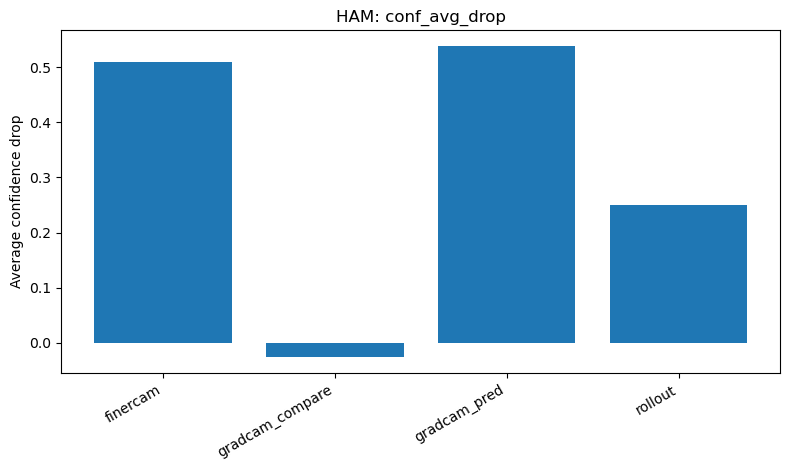

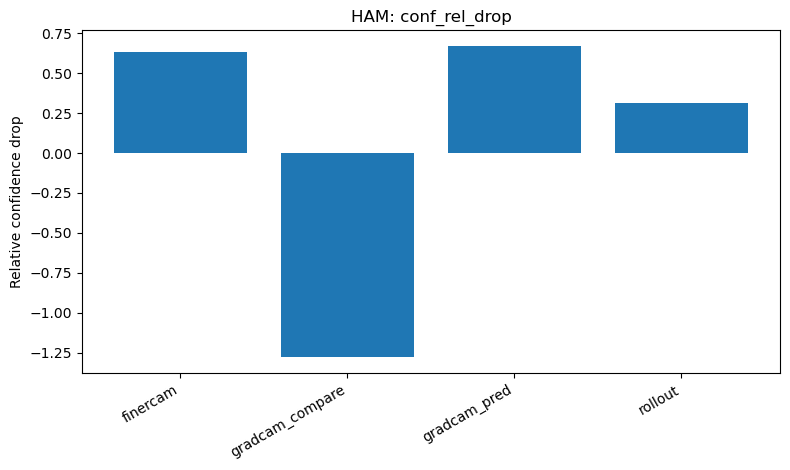

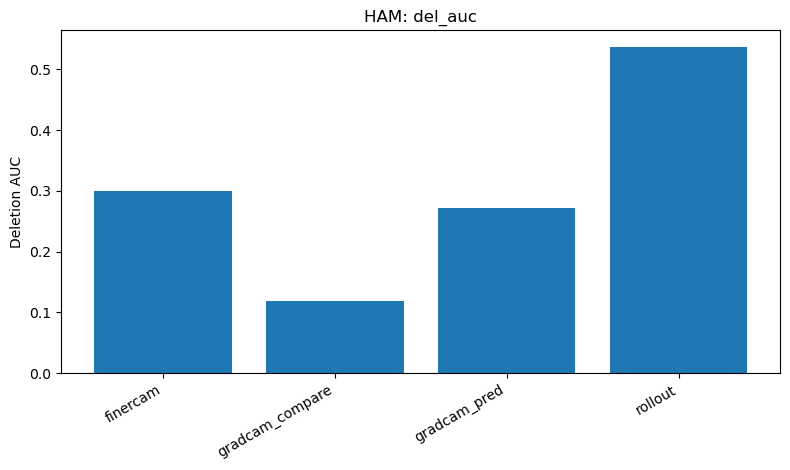

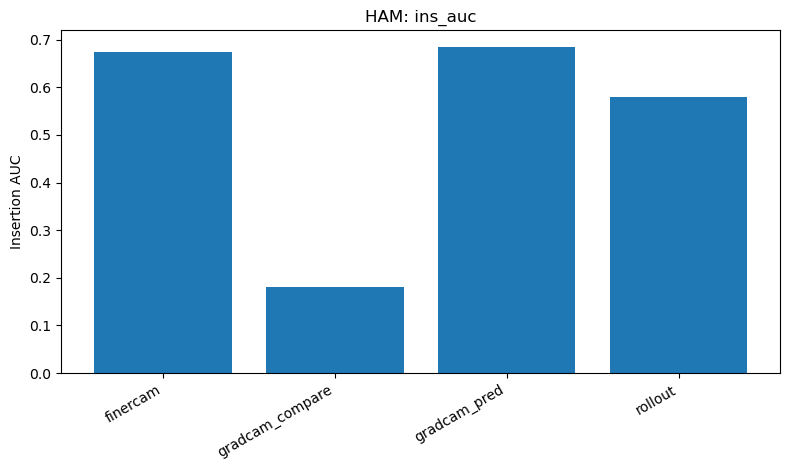

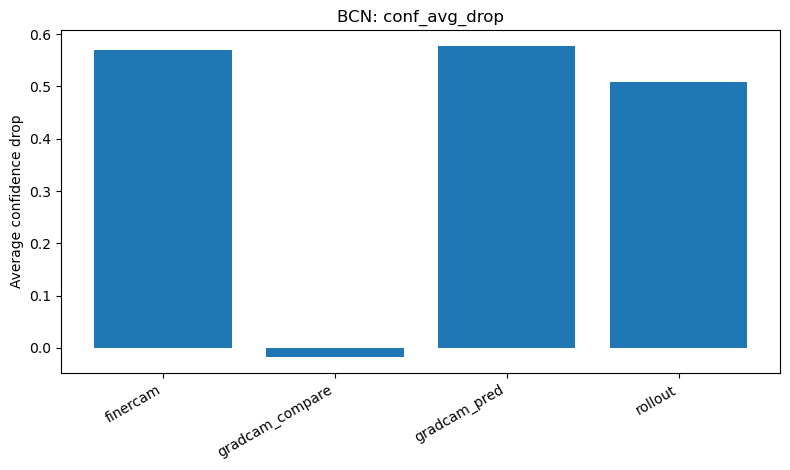

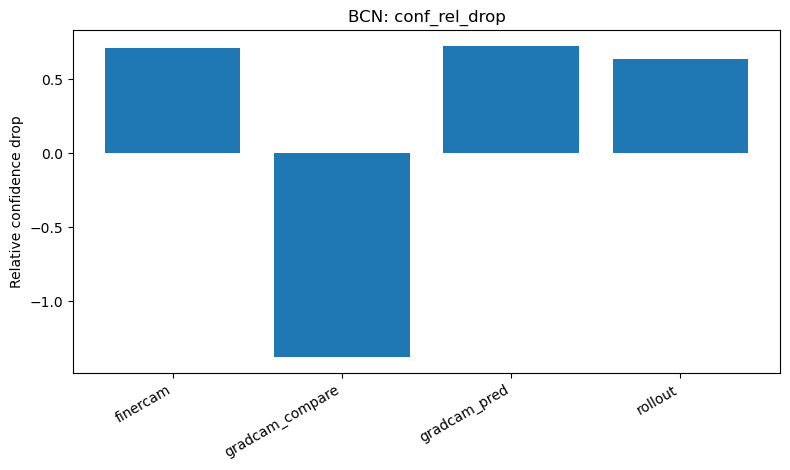

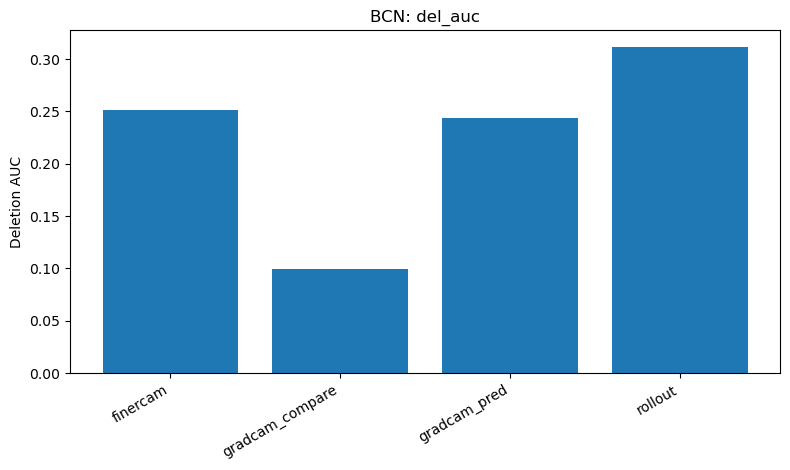

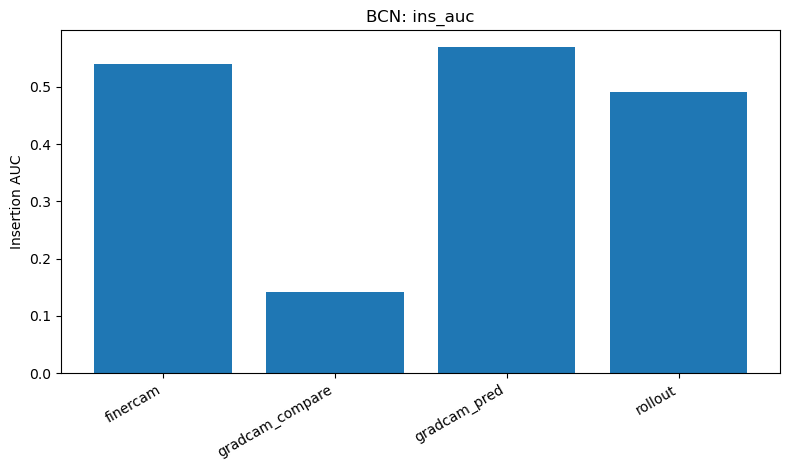

In [9]:
def plot_metric(summary_df, dataset_name, metric, ylabel):
    plot_df = summary_df.sort_values('method').reset_index(drop=True)
    plt.figure(figsize=(8, 4.8))
    plt.bar(plot_df['method'], plot_df[metric])
    plt.xticks(rotation=30, ha='right')
    plt.ylabel(ylabel)
    plt.title(f'{dataset_name}: {metric}')
    plt.tight_layout()
    plt.show()

for dataset_name, summary_df in [('HAM', ham_summary), ('BCN', bcn_summary)]:
    plot_metric(summary_df, dataset_name, 'conf_avg_drop', 'Average confidence drop')
    plot_metric(summary_df, dataset_name, 'conf_rel_drop', 'Relative confidence drop')
    plot_metric(summary_df, dataset_name, 'del_auc', 'Deletion AUC')
    plot_metric(summary_df, dataset_name, 'ins_auc', 'Insertion AUC')

## 10. Direct HAM vs BCN comparison for each metric

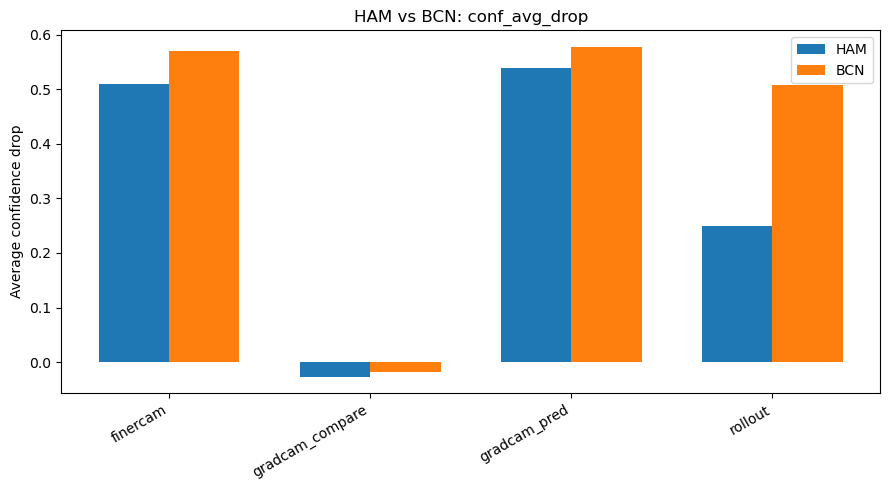

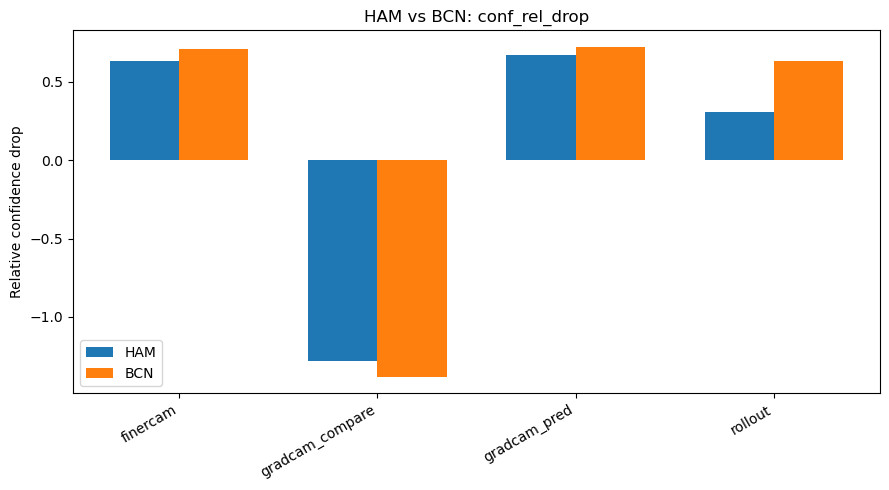

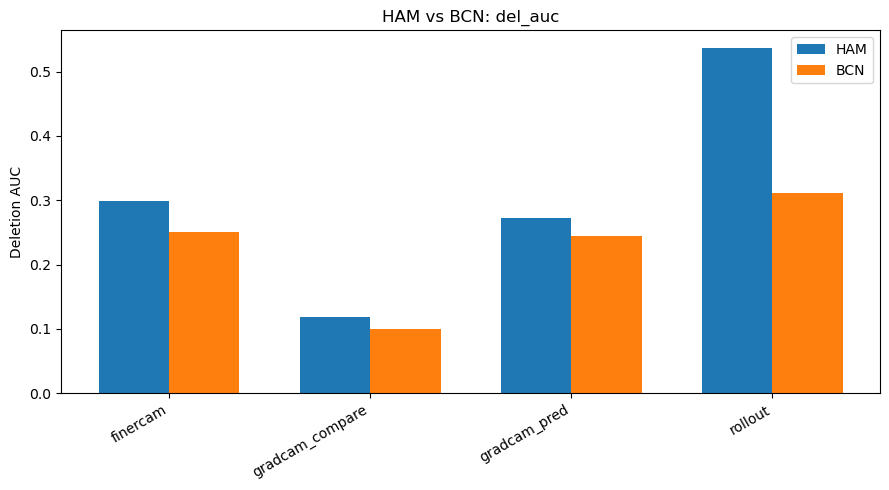

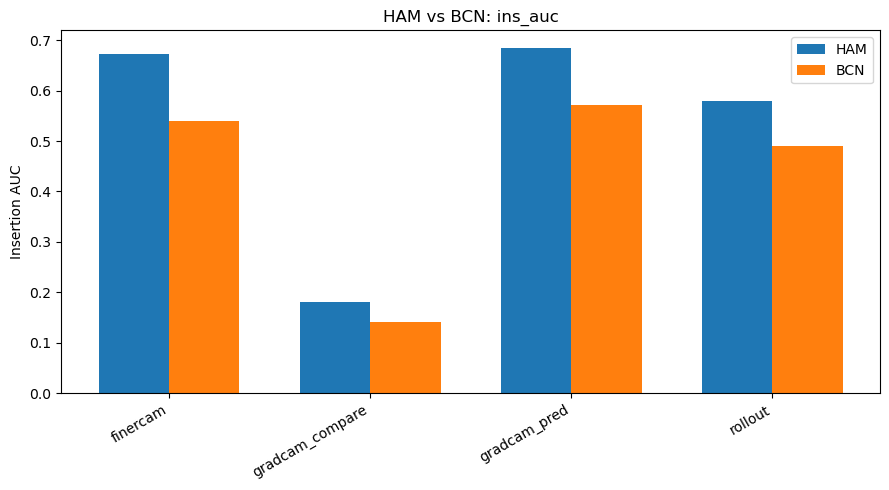

In [10]:
def plot_dataset_comparison(all_summary_df, metric, ylabel):
    pivot = all_summary_df.pivot(index='method', columns='dataset', values=metric).reset_index()
    x = np.arange(len(pivot))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, pivot['HAM'], width, label='HAM')
    plt.bar(x + width/2, pivot['BCN'], width, label='BCN')
    plt.xticks(x, pivot['method'], rotation=30, ha='right')
    plt.ylabel(ylabel)
    plt.title(f'HAM vs BCN: {metric}')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_dataset_comparison(all_summary, 'conf_avg_drop', 'Average confidence drop')
plot_dataset_comparison(all_summary, 'conf_rel_drop', 'Relative confidence drop')
plot_dataset_comparison(all_summary, 'del_auc', 'Deletion AUC')
plot_dataset_comparison(all_summary, 'ins_auc', 'Insertion AUC')

## 11. Pairwise method comparison from per-sample data

This helps check whether one method consistently beats another across images.

In [11]:
def compare_two_methods(per_sample_df, dataset_name, method_a, method_b, metric, higher_is_better=True):
    sub = per_sample_df[per_sample_df['dataset'] == dataset_name].copy()
    a = sub[sub['method'] == method_a][['image_id', metric]].rename(columns={metric: f'{method_a}_{metric}'})
    b = sub[sub['method'] == method_b][['image_id', metric]].rename(columns={metric: f'{method_b}_{metric}'})
    merged = a.merge(b, on='image_id', how='inner')

    if higher_is_better:
        wins_a = (merged[f'{method_a}_{metric}'] > merged[f'{method_b}_{metric}']).sum()
        wins_b = (merged[f'{method_b}_{metric}'] > merged[f'{method_a}_{metric}']).sum()
    else:
        wins_a = (merged[f'{method_a}_{metric}'] < merged[f'{method_b}_{metric}']).sum()
        wins_b = (merged[f'{method_b}_{metric}'] < merged[f'{method_a}_{metric}']).sum()

    ties = len(merged) - wins_a - wins_b

    return pd.DataFrame([{
        'dataset': dataset_name,
        'metric': metric,
        'method_a': method_a,
        'method_b': method_b,
        'wins_a': int(wins_a),
        'wins_b': int(wins_b),
        'ties': int(ties),
        'n': int(len(merged)),
    }])

pairwise_rows = []
for dataset_name in ['HAM', 'BCN']:
    pairwise_rows.append(compare_two_methods(all_per_sample, dataset_name, 'finercam', 'gradcam_pred', 'conf_average_drop', higher_is_better=True))
    pairwise_rows.append(compare_two_methods(all_per_sample, dataset_name, 'finercam', 'rollout', 'conf_average_drop', higher_is_better=True))
    pairwise_rows.append(compare_two_methods(all_per_sample, dataset_name, 'finercam', 'gradcam_pred', 'del_auc', higher_is_better=False))
    pairwise_rows.append(compare_two_methods(all_per_sample, dataset_name, 'finercam', 'rollout', 'del_auc', higher_is_better=False))

pairwise_df = pd.concat(pairwise_rows, ignore_index=True)
display(pairwise_df)

,dataset,metric,method_a,method_b,wins_a,wins_b,ties,n
0,HAM,conf_average_drop,finercam,gradcam_pred,34,55,11,100
1,HAM,conf_average_drop,finercam,rollout,97,3,0,100
2,HAM,del_auc,finercam,gradcam_pred,36,53,11,100
3,HAM,del_auc,finercam,rollout,97,3,0,100
4,BCN,conf_average_drop,finercam,gradcam_pred,45,54,1,100
5,BCN,conf_average_drop,finercam,rollout,70,30,0,100
6,BCN,del_auc,finercam,gradcam_pred,51,49,0,100
7,BCN,del_auc,finercam,rollout,70,30,0,100


## 12. Inspect difficult / interesting examples

Useful for choosing images for thesis figures.

In [12]:
interesting = all_per_sample.copy()
interesting = interesting[['dataset', 'image_id', 'image', 'gt_name', 'pred_name', 'compare_name', 'method', 'conf_average_drop', 'conf_relative_confidence_drop', 'del_auc', 'ins_auc']]
display(interesting.head(20))

,dataset,image_id,image,gt_name,pred_name,compare_name,method,conf_average_drop,conf_relative_confidence_drop,del_auc,ins_auc
0,HAM,ISIC_0032343,ISIC_0032343,BKL,BKL,MEL,gradcam_pred,0.209309,0.300688,0.462410,0.660627
1,HAM,ISIC_0032343,ISIC_0032343,BKL,BKL,MEL,gradcam_compare,0.068618,0.590369,0.052765,0.155919
2,HAM,ISIC_0032343,ISIC_0032343,BKL,BKL,MEL,finercam,0.231525,0.332602,0.449261,0.660056
3,HAM,ISIC_0032343,ISIC_0032343,BKL,BKL,MEL,rollout,0.042986,0.061752,0.610626,0.630977
4,HAM,ISIC_0024698,ISIC_0024698,NV,MEL,NV,gradcam_pred,0.730259,0.951336,0.058994,0.674969
5,HAM,ISIC_0024698,ISIC_0024698,NV,MEL,NV,gradcam_compare,0.009518,0.062732,0.170947,0.260184
6,HAM,ISIC_0024698,ISIC_0024698,NV,MEL,NV,finercam,0.720824,0.939045,0.070777,0.654965
7,HAM,ISIC_0024698,ISIC_0024698,NV,MEL,NV,rollout,0.674373,0.878532,0.127191,0.476270
8,HAM,ISIC_0031624,ISIC_0031624,BKL,BKL,NV,gradcam_pred,0.355852,0.585028,0.264341,0.675729
9,HAM,ISIC_0031624,ISIC_0031624,BKL,BKL,NV,gradcam_compare,0.174724,0.655304,0.119208,0.201444


In [13]:
for dataset_name in ['HAM', 'BCN']:
    print('\n' + '=' * 80)
    print(f'{dataset_name}: top FinerCAM examples by confidence drop')
    print('=' * 80)
    sub = all_per_sample[(all_per_sample['dataset'] == dataset_name) & (all_per_sample['method'] == 'finercam')]
    display(sub.sort_values('conf_average_drop', ascending=False).head(10)[['image_id', 'image', 'gt_name', 'pred_name', 'compare_name', 'conf_average_drop', 'conf_relative_confidence_drop', 'del_auc', 'ins_auc']])


HAM: top FinerCAM examples by confidence drop


,image_id,image,gt_name,pred_name,compare_name,conf_average_drop,conf_relative_confidence_drop,del_auc,ins_auc
38,ISIC_0032514,ISIC_0032514,BKL,MEL,BCC,0.842871,0.957873,0.073718,0.614931
146,ISIC_0029991,ISIC_0029991,BKL,AKIEC,BKL,0.825590,0.933211,0.090557,0.551105
262,ISIC_0030372,ISIC_0030372,BKL,BCC,AKIEC,0.825380,0.935678,0.081876,0.676895
342,ISIC_0033156,ISIC_0033156,BKL,BKL,BCC,0.801292,0.896084,0.096930,0.890208
310,ISIC_0030998,ISIC_0030998,BKL,BKL,VASC,0.788472,0.894573,0.096865,0.877452
70,ISIC_0031376,ISIC_0031376,BKL,BKL,BCC,0.784654,0.894114,0.096846,0.873653
34,ISIC_0030276,ISIC_0030276,BKL,BKL,BCC,0.782363,0.893837,0.096835,0.871374
338,ISIC_0032773,ISIC_0032773,BKL,BKL,BCC,0.781306,0.893708,0.096830,0.870322
122,ISIC_0024453,ISIC_0024453,BKL,BKL,BCC,0.780784,0.893645,0.096827,0.869803
42,ISIC_0033952,ISIC_0033952,BKL,BKL,BCC,0.775552,0.893004,0.096801,0.864598



BCN: top FinerCAM examples by confidence drop


,image_id,image,gt_name,pred_name,compare_name,conf_average_drop,conf_relative_confidence_drop,del_auc,ins_auc
590,ISIC_0054759,ISIC_0054759,melanoma,melanoma,actinic keratosis,0.810985,0.927277,0.114919,0.365632
694,ISIC_0055444,ISIC_0055444,nevus,nevus,squamous cell carcinoma,0.804908,0.908795,0.113807,0.678391
682,ISIC_0055396,ISIC_0055396,nevus,nevus,seborrheic keratosis,0.802884,0.931045,0.085501,0.601732
678,ISIC_0055338,ISIC_0055338,melanoma,melanoma,seborrheic keratosis,0.798252,0.900473,0.113123,0.510406
766,ISIC_0055758,ISIC_0055758,nevus,nevus,actinic keratosis,0.774838,0.892839,0.130350,0.614276
762,ISIC_0055755,ISIC_0055755,seborrheic keratosis,melanoma,seborrheic keratosis,0.761975,0.875670,0.131202,0.548756
614,ISIC_0054897,ISIC_0054897,seborrheic keratosis,seborrheic keratosis,dermatofibroma,0.757009,0.873423,0.113492,0.862930
534,ISIC_0054362,ISIC_0054362,nevus,nevus,melanoma,0.755489,0.902776,0.090425,0.476743
774,ISIC_0055826,ISIC_0055826,melanoma,melanoma,seborrheic keratosis,0.754272,0.874234,0.148584,0.526389
426,ISIC_0053623,ISIC_0053623,melanoma,melanoma,actinic keratosis,0.751544,0.878836,0.129802,0.185757


## 13. Optional: deletion / insertion curves from `metrics_full.json`

This works if your JSON stores curve arrays for each sample.

In [14]:
def extract_mean_curve(full_records, method_name, metric_key, curve_key):
    curves = []
    for rec in full_records:
        if rec.get('method') != method_name:
            continue
        metric = rec.get(metric_key, {})
        curve = metric.get(curve_key)
        if curve is not None and len(curve) > 1:
            curves.append(np.asarray(curve, dtype=float))
    if len(curves) == 0:
        return None
    min_len = min(len(c) for c in curves)
    curves = np.stack([c[:min_len] for c in curves], axis=0)
    return curves.mean(axis=0)

In [15]:
def plot_curves_if_available(full_records, dataset_name):
    methods = ['gradcam_pred', 'gradcam_compare', 'finercam', 'rollout']

    plt.figure(figsize=(8, 5))
    something = False
    for method in methods:
        curve = extract_mean_curve(full_records, method, 'deletion', 'curve') if full_records else None
        if curve is not None:
            plt.plot(np.linspace(0, 1, len(curve)), curve, label=method)
            something = True
    if something:
        plt.title(f'{dataset_name}: mean deletion curves')
        plt.xlabel('Fraction removed')
        plt.ylabel('Target confidence')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f'{dataset_name}: no deletion curves available in metrics_full.json')

    plt.figure(figsize=(8, 5))
    something = False
    for method in methods:
        curve = extract_mean_curve(full_records, method, 'insertion', 'curve') if full_records else None
        if curve is not None:
            plt.plot(np.linspace(0, 1, len(curve)), curve, label=method)
            something = True
    if something:
        plt.title(f'{dataset_name}: mean insertion curves')
        plt.xlabel('Fraction inserted')
        plt.ylabel('Target confidence')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f'{dataset_name}: no insertion curves available in metrics_full.json')

plot_curves_if_available(ham_full, 'HAM')
plot_curves_if_available(bcn_full, 'BCN')

HAM: no deletion curves available in metrics_full.json
HAM: no insertion curves available in metrics_full.json
BCN: no deletion curves available in metrics_full.json
BCN: no insertion curves available in metrics_full.json


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

## 14. Thesis-ready compact table

In [16]:
thesis_table = all_summary[['dataset', 'method', 'conf_avg_drop', 'conf_rel_drop', 'del_auc', 'ins_auc']].copy()
for c in ['conf_avg_drop', 'conf_rel_drop', 'del_auc', 'ins_auc']:
    thesis_table[c] = thesis_table[c].map(lambda x: round(float(x), 3))
display(thesis_table.sort_values(['dataset', 'method']).reset_index(drop=True))

,dataset,method,conf_avg_drop,conf_rel_drop,del_auc,ins_auc
0,BCN,finercam,0.569,0.714,0.251,0.540
1,BCN,gradcam_compare,-0.018,-1.381,0.099,0.141
2,BCN,gradcam_pred,0.578,0.725,0.244,0.571
3,BCN,rollout,0.509,0.636,0.312,0.491
4,HAM,finercam,0.509,0.635,0.299,0.674
5,HAM,gradcam_compare,-0.026,-1.281,0.118,0.181
6,HAM,gradcam_pred,0.539,0.671,0.272,0.685
7,HAM,rollout,0.249,0.311,0.538,0.580


## 15. Short interpretation notes

After running this notebook, write down:
1. whether rollout is consistently weaker
2. whether FinerCAM is better than GradCAM(pred) quantitatively, similar, or worse
3. whether FinerCAM still looks qualitatively more useful for differential diagnosis
4. whether HAM and BCN show the same trend

That will likely become the basis for your Results section.